## Introduction

This work is based on <a href="#ref1">[1]</a> as part of my bachelor's thesis. In that work, singular spectrum analysis (SSA) is employed for the first time on data from the Fermi-LAT Space Telescope to study periodicities on the light curves of several blazars. The aim of using SSA is to isolate the periodic behaviour of the emissions from long-term trends and noise, and then compute the Lomb-Scargle periodogram (LSP) on the isolated oscillatory component to determine the most significant periods.
As a result, 46 blazars are identified as potential candidates for quasi-periodic oscillations (QPOs), which provides a foundation for future investigations on the detection of binary supermas
sive black hole (SMBHs) systems.

Blazar PG1553+113 will be used as sample since it is the same one used on <a href="#ref1">[1]</a>. The first task is importing the functions we will be using and getting the light curve (LC) data. 

In [1]:
from blazar_tools import GetLCRData, plot_analysis, time_splits, plot_split_pgram, SSA, SSA_pyts, mjd_to_year, year_to_mjd, Periodogram
import pandas as pd
import numpy as np
from ftperiodogram.modeler import FastTemplatePeriodogram, FastMultiTemplatePeriodogram, TemplateModel
from ftperiodogram.template import Template
import matplotlib.pyplot as plt

In [2]:
path = '../data/enlacesCurvas.txt'
blazar = 'PG1553+113'
LCR_data = GetLCRData(path)
df_data= LCR_data.df_dict[blazar]
df_data.head()

,t_met,flux,flux_error,t_mjd,t_year
0,240883201.0,7.220000e-08,6.800000e-09,54698.000012,2008.635181
1,243475201.0,5.090000e-08,6.500000e-09,54728.000012,2008.717317
2,248659201.0,6.970000e-08,7.500000e-09,54788.000012,2008.881588
3,251251201.0,6.180000e-08,6.200000e-09,54818.000012,2008.963724
4,253843201.0,4.160000e-08,5.800000e-09,54848.000012,2009.045859


# 1. Current methodology

### Singular spectrum analysis

The SSA is a powerful technique for time series analysis with multiple applications in mathematics, physics or economics. The method consists in two main stages: decomposition of the series into its components, and reconstruction to separate long term trends and noise from the oscillatory components. 

We have implemented an algorithm to do that for us. In the decompostion stage of the signal, the only parameter we need to set is the window lenght $L$, which is an integer such that $2 \leq L \leq N/2$, being $N$ the number of components of the time series. This parameter sets how the time series is embeded into a multidimensional series with vectors of lenght $L$. If the time series contains a periodic component with an integer period it is recommended to set the window length proportional to that period. A window lenght fullfiling these conditions that works well is $L = 0.4 N$.

The decomposition is performed as follows:

In [3]:
flux = df_data.flux.values
t_mjd = df_data.t_mjd.values

n = len(flux)
L = int(0.4 * n) # L must be an integer

ssa = SSA(t_mjd, flux, L)

The next step is reconstruction. After the decompostion, we can asses the quality of the separation of signal and noise components by observing the correlations among the different components. SSA presents the components sorting them by importance. This importance is measured from their eigenvalues during the decomposition process. Therefore, we will have a look to the first 10 more important components and their correlations. 

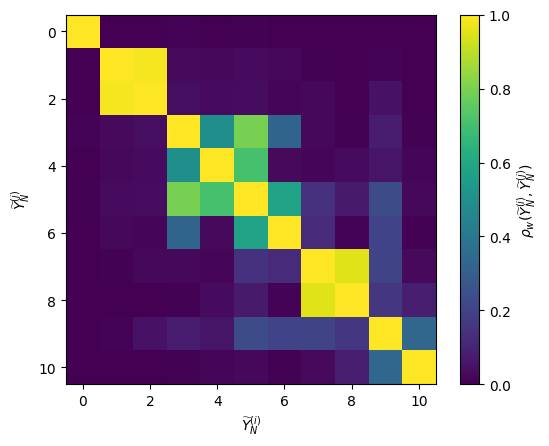

In [4]:
ssa.plot_wcorr(max = 10)

TThe correlation is measured from 0 to 1, being 1 the self correlation, and therefore a value present in the diagonal. As a first approximation, there is a clear division between three groups: 
- Component 0, which is the slowest varying component. This will be the trend.
- Components 1 and 2, which are the next most significant group of components. These will form the oscillatory component.
- The rest of the components are less important and will be treated as noise. 

Following this pipeline, an automatic reconstruction algorithm is defined which groups the most correlated components from the begining as the oscillatory component, then groups all the previous components as trend, an the rest as noise. 

In [5]:
df_ssa = ssa.auto_reconstruction()
df_ssa.head()

,trend,oscillatory,noise
54698.000012,4.210185e-08,8.343866e-09,2.171057e-08
54728.000012,4.215216e-08,7.029499e-09,1.738321e-09
54788.000012,4.219041e-08,5.407917e-09,2.213768e-08
54818.000012,4.211442e-08,3.326786e-09,1.630067e-08
54848.000012,4.207137e-08,1.043195e-09,-1.486441e-09


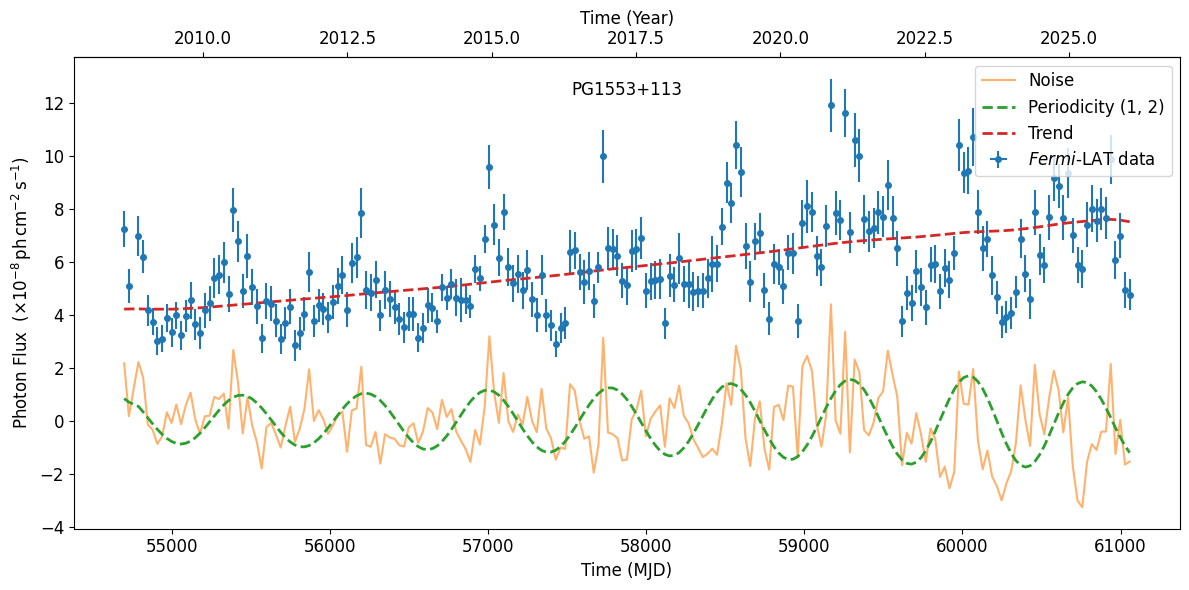

In [6]:
plot_analysis(df_data, df_ssa, blazar)

###  Lomb-Scargle periodogram

LSP is based on perfmoring a least sequare fitting of sinusoidal function to a given data. The power of each period is related to how good the fit is using a sinusoidal function of that frequency. The result is the so called periodogram, which represents the power of each fitted period. 
The detected period will be taken as the period corresponding to the peak of the periodogram and its uncertainty will be the FWHM of the gaussian function that best fits the peak. The LSP is performed for the oscillatory component only.

Full LSP Period detected: 2.09 +- 0.23 yr


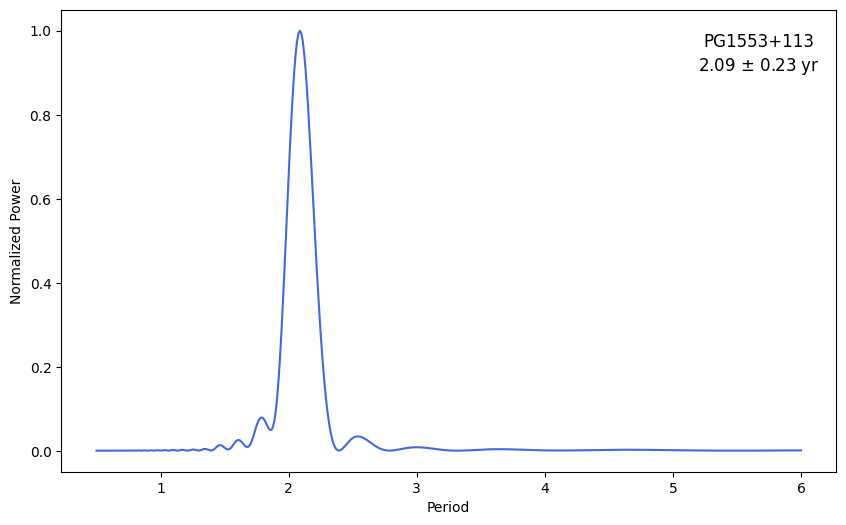

In [7]:
per = Periodogram(df_ssa, blazar)
pgram_dict = per.LSP()

## 2. New methodologies

### Time splits test

A way of testing the persistence of the periodic oscillations is splitting the LC data in two halves and then appliying the same pipeline. This is: SSA and LSP on each half. The periodicity persists if the period detected in both halves, within a reasonable tolerance.

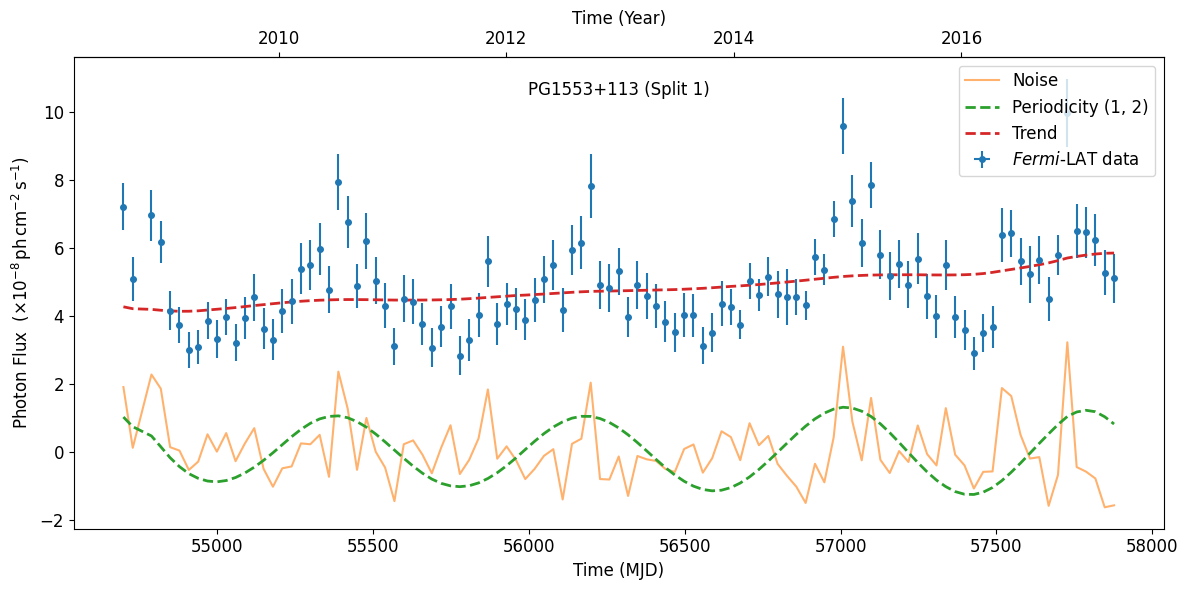

 Split 1 LSP Period detected: 2.20 +- 0.50 yr


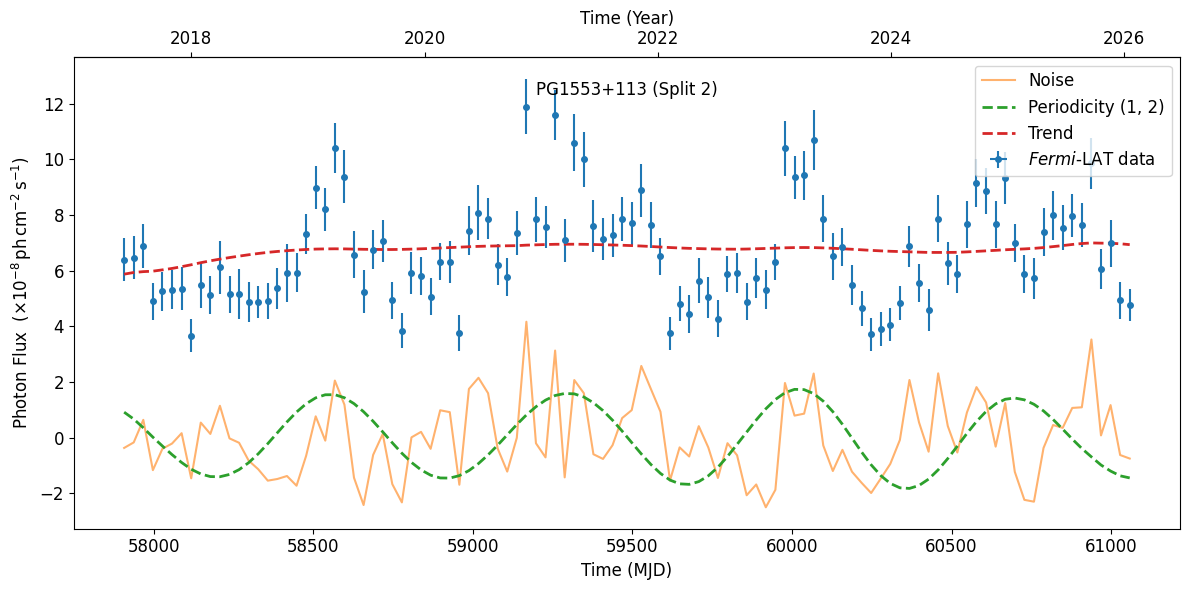

 Split 2 LSP Period detected: 1.98 +- 0.40 yr


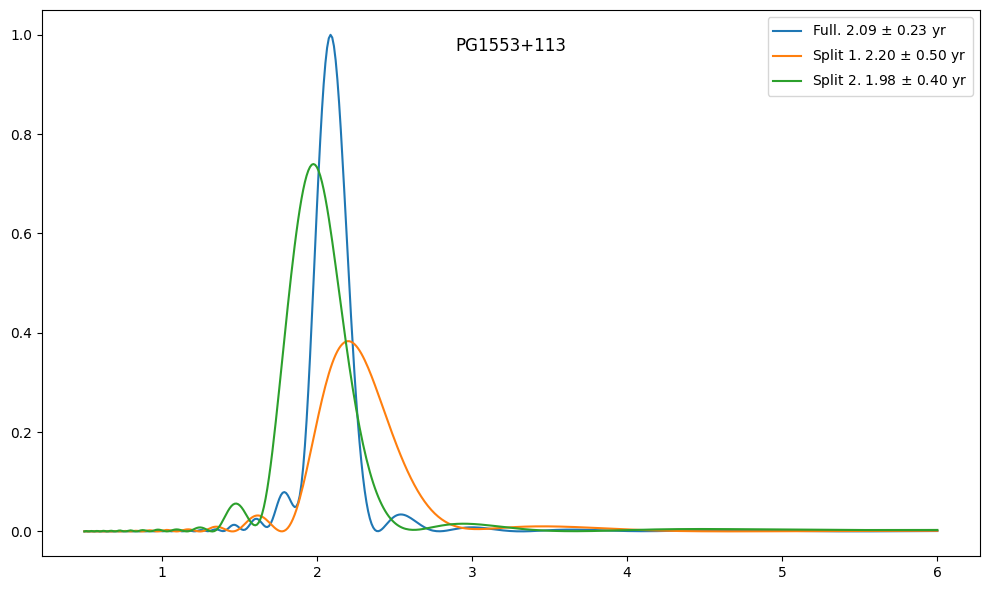

In [8]:
splits = 2
overlap = 0
df_list = time_splits(df_data, splits =2, overlap = overlap)

LSP_list = [pgram_dict]
for i in range(splits):
    split = i+1
    df = df_list[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    
    L = int(0.4*len(time_mjd_split))
    ssa = SSA(time_mjd_split, flux_split, L)
    df_ssa_split = ssa.auto_reconstruction()
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.LSP(plot=False)
    LSP_list.append(LSP_result)

plot_split_pgram(LSP_list, blazar)


### Deeper into SSA reconstruction

The algorith previously used works but only consider one pair to form the oscillatory component. This approximation may not be enough in many cases since relevant information about the oscillation could be cathegorized as noise. 
A different approach in the reconstruction step suggests considering how the different components evolve in time, instead of using correlations. Under this perspective, a new classification method is applied, by setting a lower frequency bound and a parameter for frequency contribution. The periodogram is computed for each component. Then:

- If its power is concentrated towards the lower frequency region, under the bound, such that its contribution in that region is greater than the parameter we set, that component will be consider as trend.
- If its power is concentrated towards the higher region of the periodogram, or is not evenly distributed, such that less than parameter we set is contained in the first half of the periodogram, that component will be considered as noise.
- The rest of the components will be considered as oscillatory.



In [9]:
freq_bound = 0.03
c_bound = 0.92
df_ssa_pyts = SSA_pyts(t_mjd, flux, L, freq_bound = freq_bound, c_bound = c_bound)

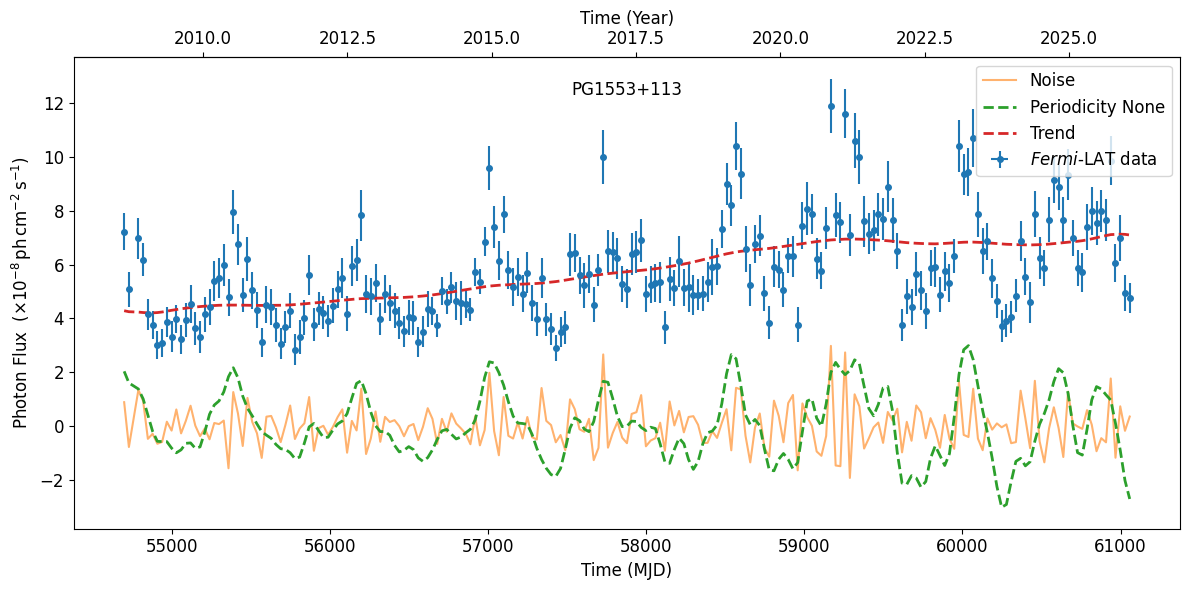

In [10]:
plot_analysis(df_data, df_ssa_pyts, blazar)

The same flow is applied now. This is, computing the LSP and then comparing the result with the oone obtained for the splits.

 Split 2 LSP Period detected: 1.98 +- 0.40 yr


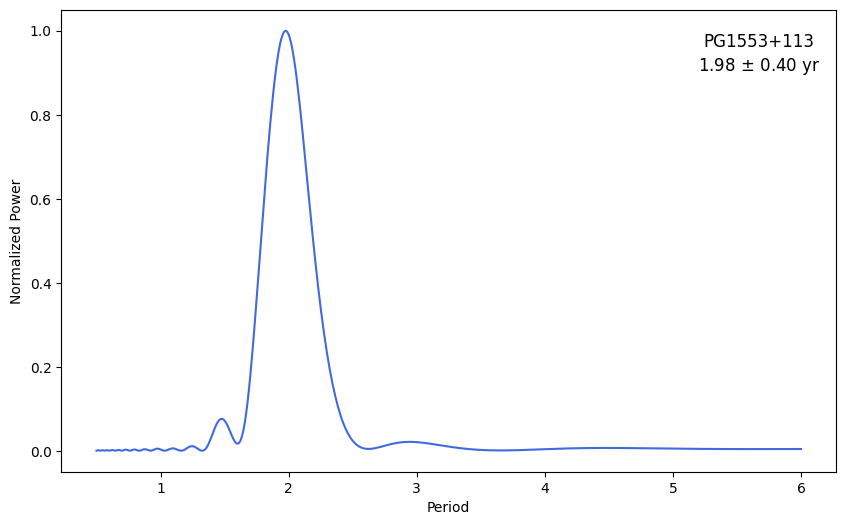

In [11]:
per_pyts = Periodogram(df_ssa_pyts, blazar)
pgram_dict_pyts = per.LSP()

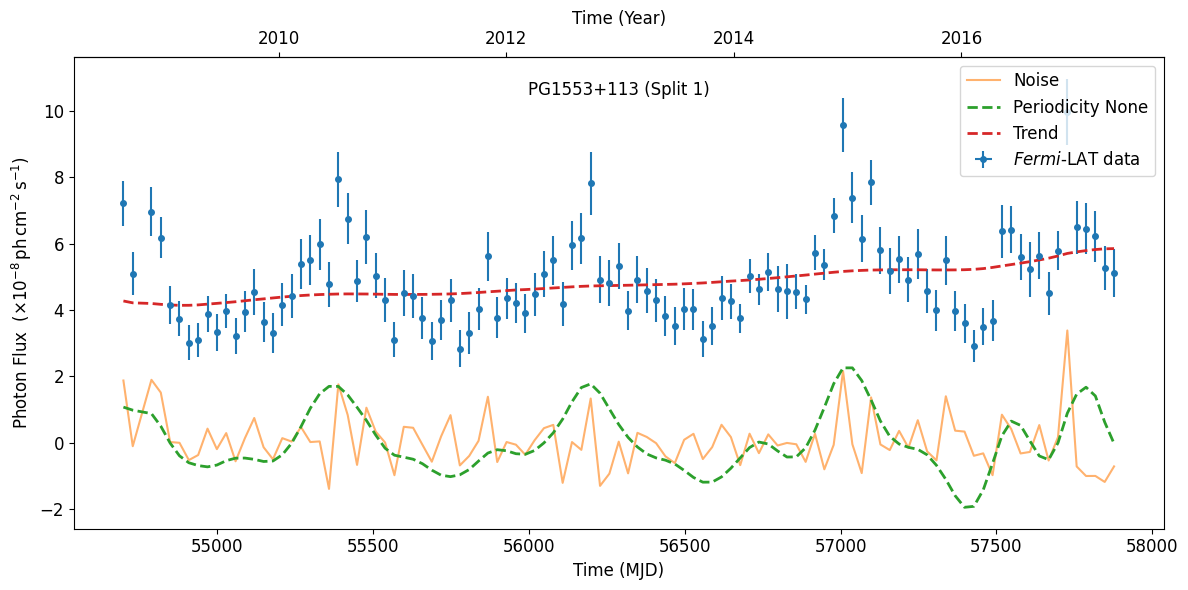

 Split 1 LSP Period detected: 2.18 +- 0.50 yr


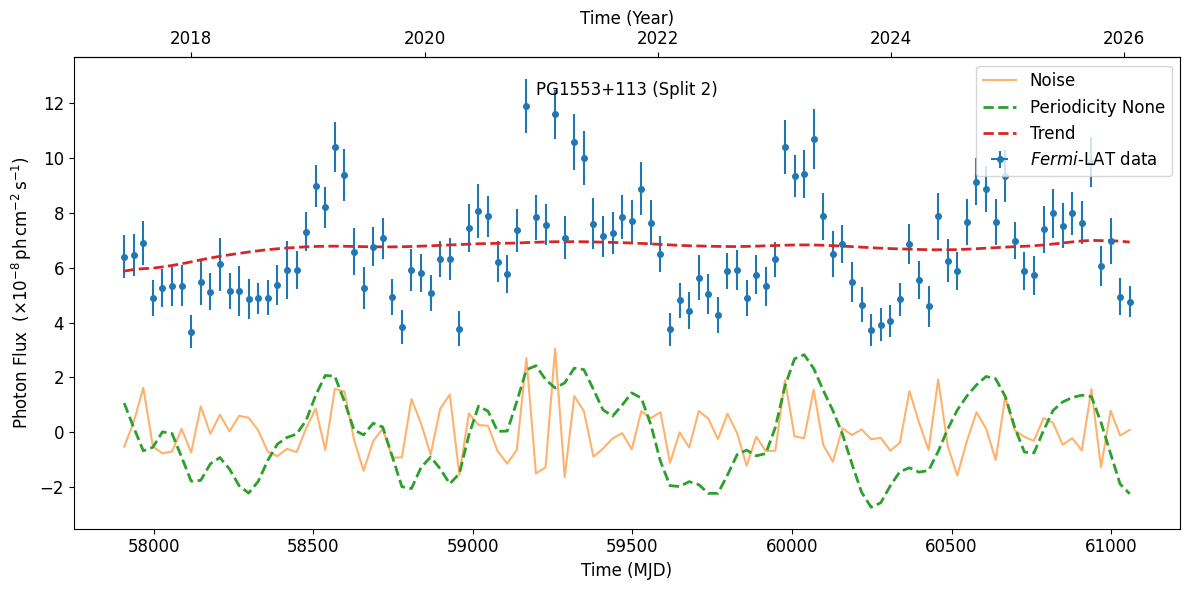

 Split 2 LSP Period detected: 1.99 +- 0.43 yr


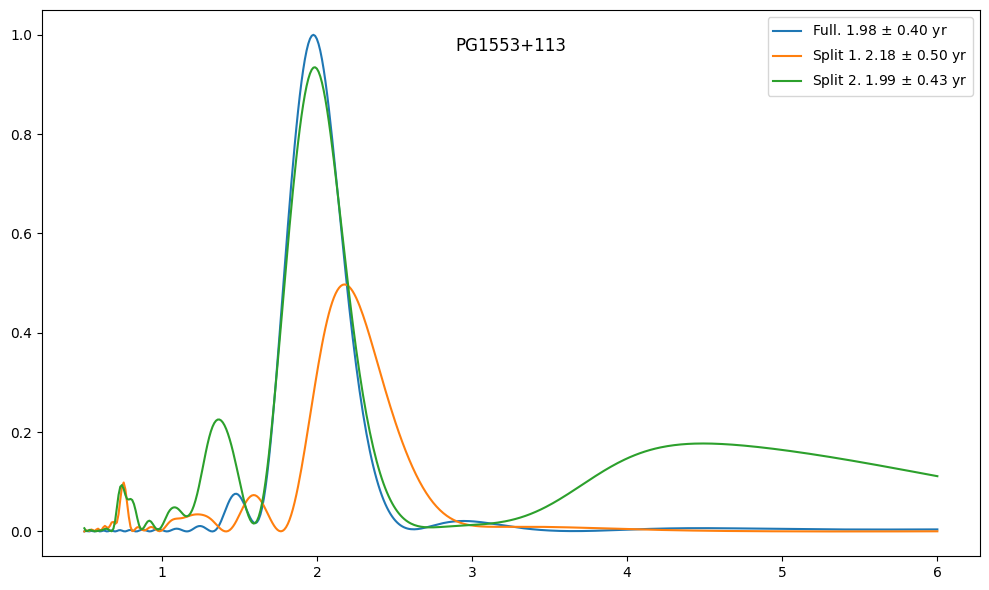

In [12]:
splits = 2
overlap = 0
df_list_pyts = time_splits(df_data, splits =2, overlap = overlap)

LSP_list_pyts = [pgram_dict_pyts]
for i in range(splits):
    split = i+1
    df = df_list_pyts[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    L = int(0.4*len(time_mjd_split))
    df_ssa_split = SSA_pyts(time_mjd_split, flux_split, L, 
                            freq_bound = freq_bound, c_bound = c_bound)
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.LSP(plot=False)
    LSP_list_pyts.append(LSP_result)

plot_split_pgram(LSP_list_pyts, blazar)

### Fast Template Periodogram: a first aplication in the search of blazar's periodicities

As explaine before, to computation of the LSP is based on fitting a sinusoidal function. The advantange of FTP is that this method allows any other pre defined function as a template. Since PG 1553+113 is a very good sample of regular oscillations, we can define a sample from this LC and try to fit it to other blazars. If the behaviour is the same, the attempt to fit this template will be succesful. We will use the oscillatory component from the previous SSA as the template.

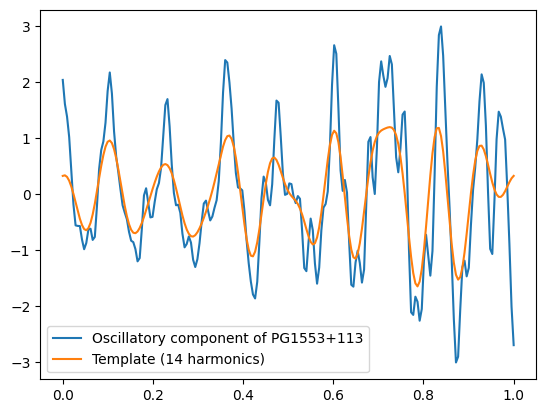

In [13]:
time = df_ssa_pyts.index.values
flux = df_ssa_pyts.oscillatory.values / 1e-8

x = np.linspace(0, 1, len(flux))
nharmonics = 14
template = Template.from_sampled(flux, nharmonics= nharmonics, template_id = f'PG1553 Template')
plt.plot(x,flux, label = 'Oscillatory component of PG1553+113')
plt.plot(x,template(x), label = f'Template ({nharmonics} harmonics)')
plt.legend()
plt.show()

This template should fit quite well on PG 1553+113, since in has been defined from itself. Therefore, the detected period should be tha same that was computed from LSP. Let us do the test.

Full FTP PG1553 Template Period detected: 2.02 +- 0.36 yr


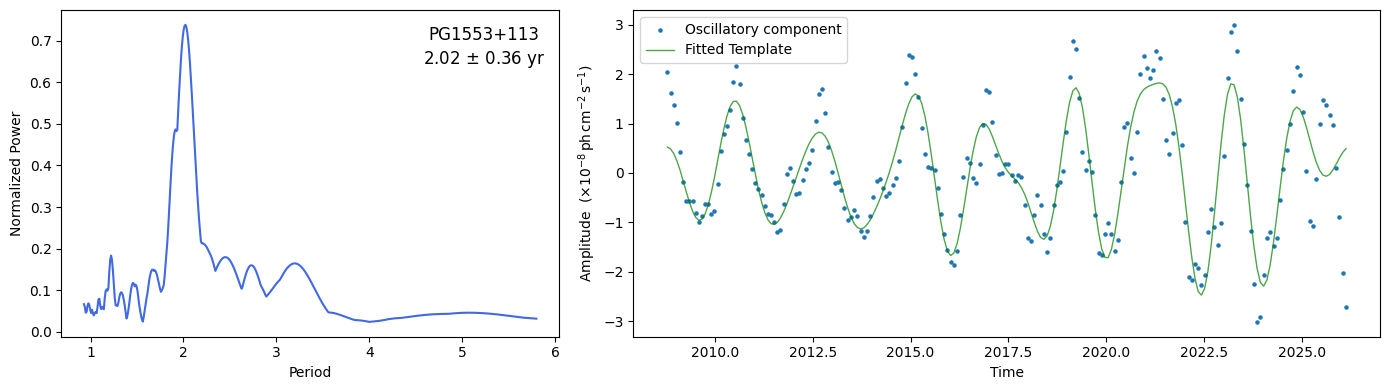

In [14]:
per = Periodogram(df_ssa_pyts, blazar)
pgram_dict_full = per.FTP(template)

Also, we expect the same result with the time split test.

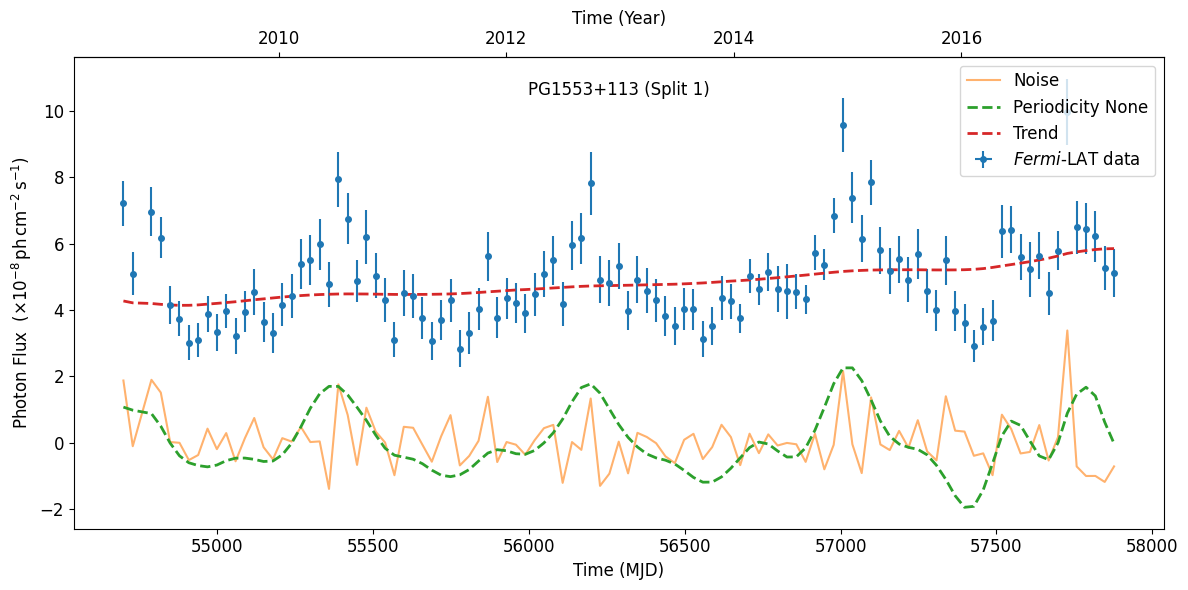

FTP PG1553 Template Split: 1 Period detected: 2.02 +- 0.70 yr


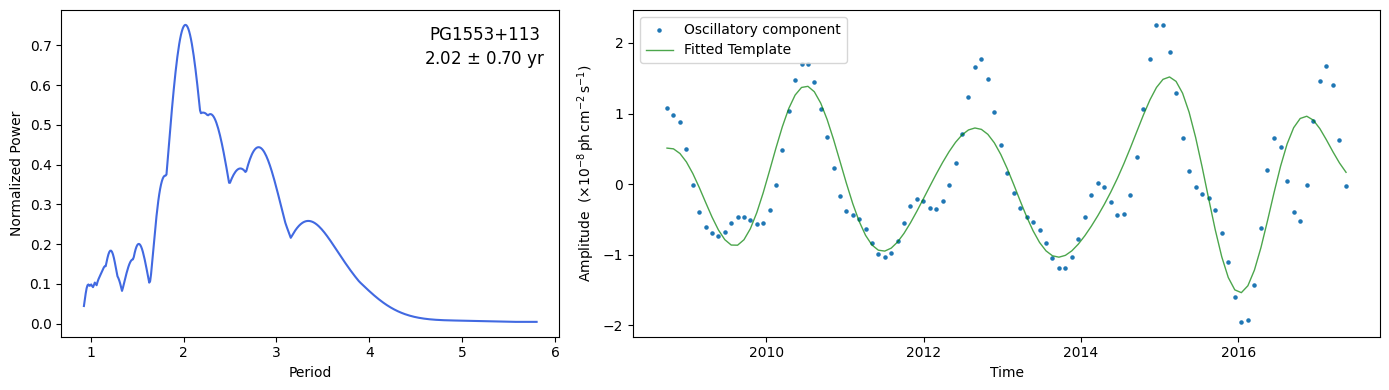

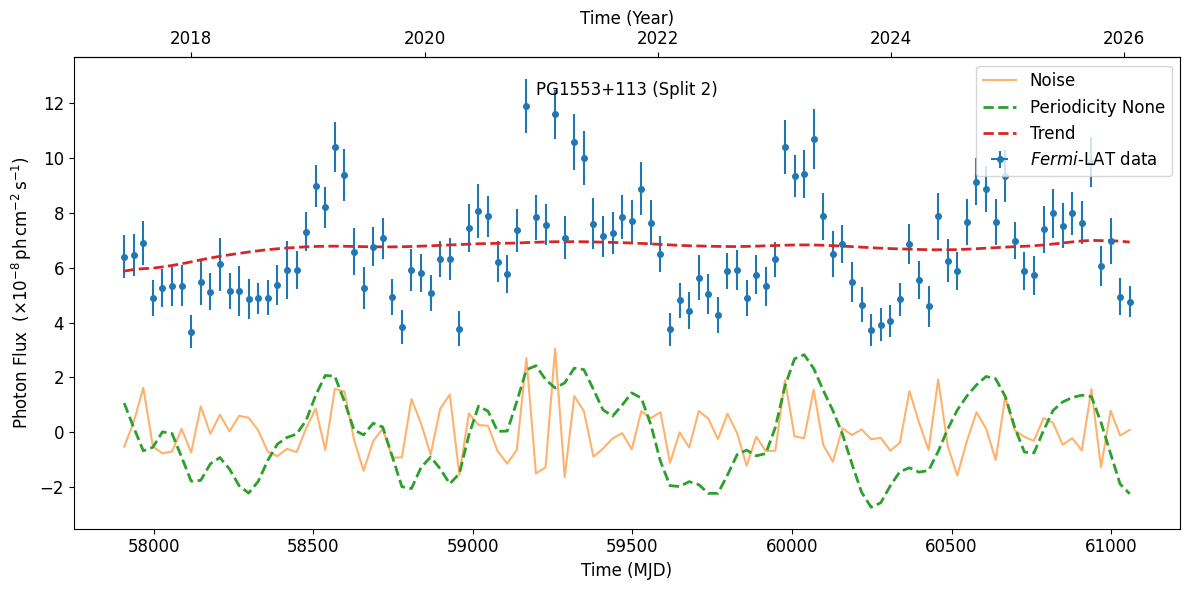

FTP PG1553 Template Split: 2 Period detected: 2.01 +- 0.69 yr


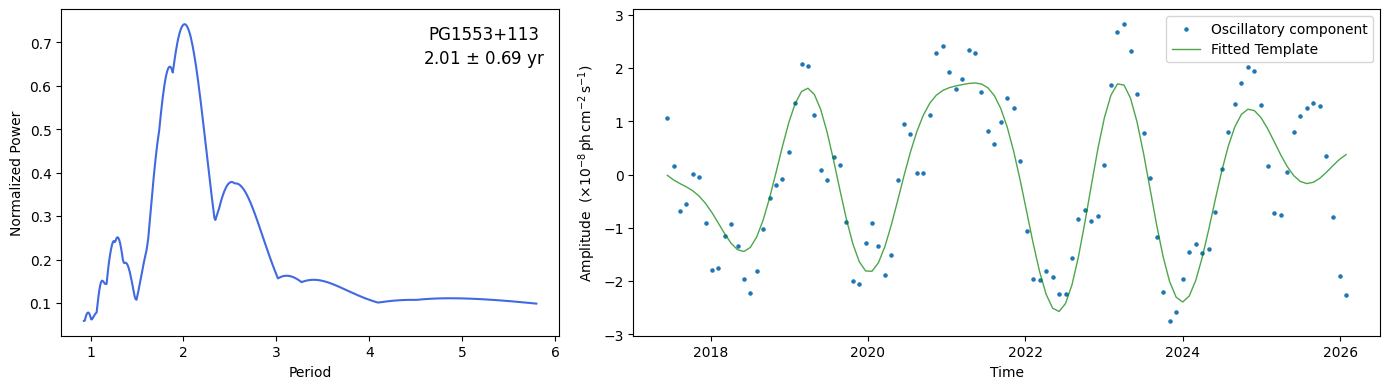

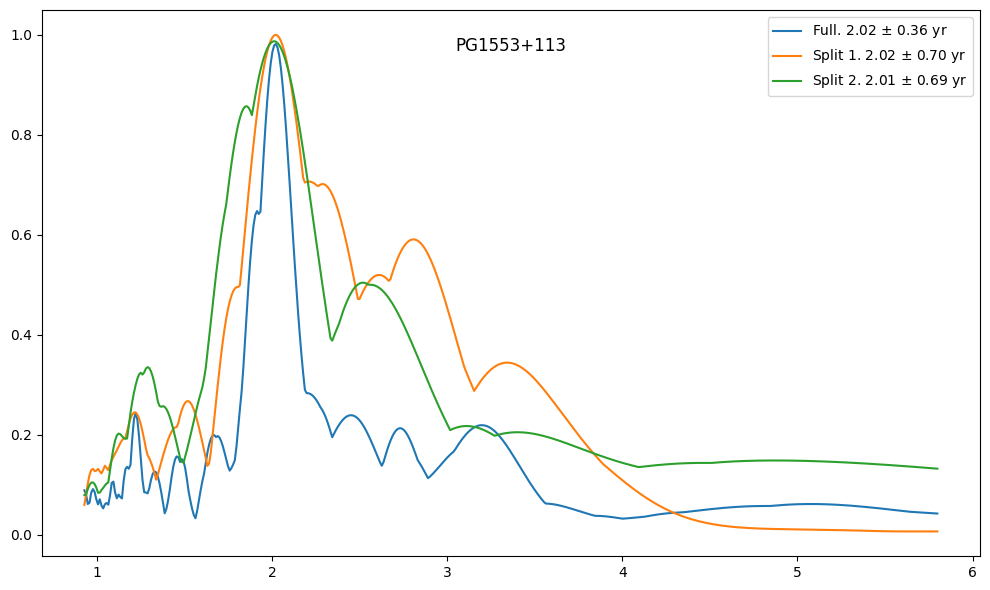

In [15]:
splits = 2
df_list_pyts = time_splits(df_data, splits =2)

freq_bound = 0.03
c_bound = 0.92

LSP_list_pyts = [pgram_dict_full]
for i in range(splits):
    split = i+1
    df = df_list_pyts[i]
    # SSA and LSP periodogram
    time_mjd_split = df.t_mjd.values
    flux_split = df.flux.values
    L = int(0.4*len(time_mjd_split))
    df_ssa_split = SSA_pyts(time_mjd_split, flux_split, L, 
                            freq_bound = freq_bound, c_bound = c_bound)
    plot_analysis(df, df_ssa_split, blazar, split = split)
    
    per = Periodogram(df_ssa_split, blazar, split = split)
    LSP_result = per.FTP(template)
    LSP_list_pyts.append(LSP_result)

plot_split_pgram(LSP_list_pyts, blazar)

This method is applied to other candidates for QPOs (e.g. PKS2155-304), and similar results from the ones of <a href="#ref1">[1]</a> are found.

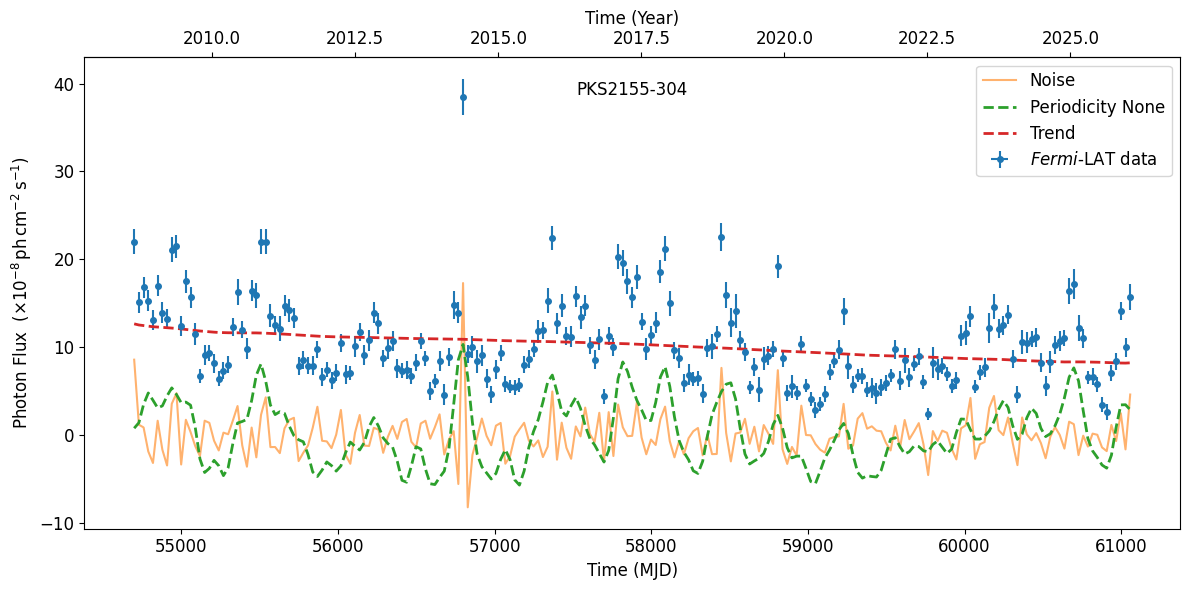

Full FTP PG1553 Template Period detected: 1.63 +- 0.74 yr


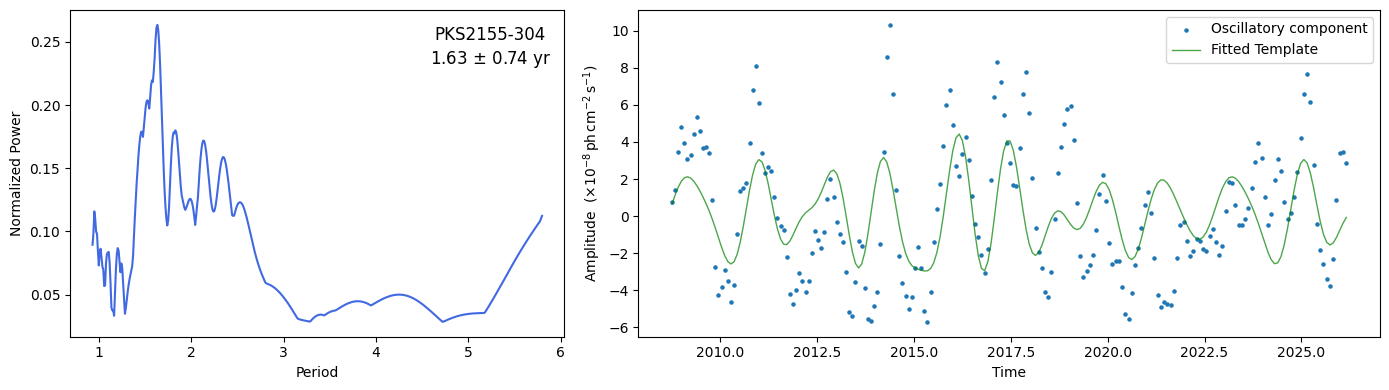

In [16]:
blazar = 'PKS2155-304'
df_data= LCR_data.df_dict[blazar]
if 'upper_limits' in df_data.columns:
    df_data['flux_ssa'] = df_data[['flux', 'upper_limits']].sum(axis=1).values
else:
    df_data['flux_ssa'] = df_data.flux
    

# Full SSA and LSP periodogram
time_mjd = df_data.t_mjd.values
flux_ssa = df_data.flux_ssa.values
L = int(0.4*len(time_mjd))
df_ssa = SSA_pyts(time_mjd, flux_ssa, L, freq_bound = freq_bound, c_bound = c_bound)

plot_analysis(df_data, df_ssa, blazar)
per = Periodogram(df_ssa, blazar)
pgram_dict_full = per.FTP(template)

## 3. Machine Learning applied to periodicity detection

...

### Training the model: LC simulation

...

## References

<a name="ref1">[1]</a> A. Rico et al., «Singular spectrum analysis of Fermi-LAT blazar light curves: A systematic search for periodicity and trends in the time domain», A&A, vol. 697, p. A35, may 2025, doi: 10.1051/0004-6361/202452495.

<a name="ref1">[2]</a> J. Hoffman, J. Vanderplas, J. Hartman, y G. Bakos, «A Fast Template Periodogram for Detecting Non-sinusoidal Fixed-shape Signals in Irregularly Sampled Time Series», 7 de febrero de 2021, arXiv: arXiv:2101.12348. doi: 10.48550/arXiv.2101.12348.



